---
#### 3-3. ML 실습 - 분류1 
- USA Adult(Census Income)
---

In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid')

#### 1. 데이터 확인

In [2]:
# data loading 
train = pd.read_csv('data/usa_people_train.csv')
test = pd.read_csv('data/usa_people_test.csv')

print(train.shape)
train.head()

(29304, 16)


,id,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,3331,34.0,State-gov,177331,Some-college,10,Married-civ-spouse,Prof-specialty,Husband,Black,Male,4386,0,40.0,United-States,>50K
1,19749,58.0,Private,290661,HS-grad,9,Married-civ-spouse,Craft-repair,Husband,White,Male,0,0,40.0,United-States,<=50K
2,1157,48.0,Private,125933,Some-college,10,Widowed,Exec-managerial,Unmarried,Black,Female,0,1669,38.0,United-States,<=50K
3,693,58.0,Private,100313,Some-college,10,Married-civ-spouse,Protective-serv,Husband,White,Male,0,1902,40.0,United-States,>50K
4,12522,41.0,Private,195661,Some-college,10,Married-civ-spouse,Transport-moving,Husband,White,Male,0,0,54.0,United-States,<=50K


In [3]:
print(test.shape)
test.head()

(3257, 15)


,id,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country
0,11574,39.0,State-gov,114055,Bachelors,13,Never-married,Exec-managerial,Not-in-family,White,Female,0,0,40.0,United-States
1,15847,38.0,Private,254114,Some-college,10,Married-spouse-absent,Prof-specialty,Own-child,Black,Female,0,0,40.0,United-States
2,17655,44.0,State-gov,55395,HS-grad,9,Never-married,Craft-repair,Not-in-family,White,Male,0,0,NaN,United-States
3,19790,47.0,Private,28035,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,50.0,United-States
4,31812,62.0,NaN,186611,HS-grad,9,Never-married,NaN,Not-in-family,White,Male,0,0,40.0,United-States


In [4]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29304 entries, 0 to 29303
Data columns (total 16 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              29304 non-null  int64  
 1   age             29292 non-null  float64
 2   workclass       27642 non-null  object 
 3   fnlwgt          29304 non-null  int64  
 4   education       29304 non-null  object 
 5   education.num   29304 non-null  int64  
 6   marital.status  29304 non-null  object 
 7   occupation      27636 non-null  object 
 8   relationship    29304 non-null  object 
 9   race            29304 non-null  object 
 10  sex             29304 non-null  object 
 11  capital.gain    29304 non-null  int64  
 12  capital.loss    29304 non-null  int64  
 13  hours.per.week  29291 non-null  float64
 14  native.country  28767 non-null  object 
 15  income          29304 non-null  object 
dtypes: float64(2), int64(5), object(9)
memory usage: 3.6+ MB


In [5]:
train.isnull().sum()

id                   0
age                 12
workclass         1662
fnlwgt               0
education            0
education.num        0
marital.status       0
occupation        1668
relationship         0
race                 0
sex                  0
capital.gain         0
capital.loss         0
hours.per.week      13
native.country     537
income               0
dtype: int64

#### 2-1. EDA

In [6]:
train.describe()

,id,age,fnlwgt,education.num,capital.gain,capital.loss,hours.per.week
count,29304.000000,29292.000000,2.930400e+04,29304.000000,29304.000000,29304.000000,29291.000000
mean,16264.027880,38.553223,1.897488e+05,10.080842,1093.858722,86.744506,40.434229
std,9384.518323,13.628811,1.055250e+05,2.570824,7477.435640,401.518928,12.324036
min,0.000000,-38.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,8145.750000,28.000000,1.177890e+05,9.000000,0.000000,0.000000,40.000000
50%,16253.500000,37.000000,1.783765e+05,10.000000,0.000000,0.000000,40.000000
75%,24374.250000,48.000000,2.370682e+05,12.000000,0.000000,0.000000,45.000000
max,32560.000000,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


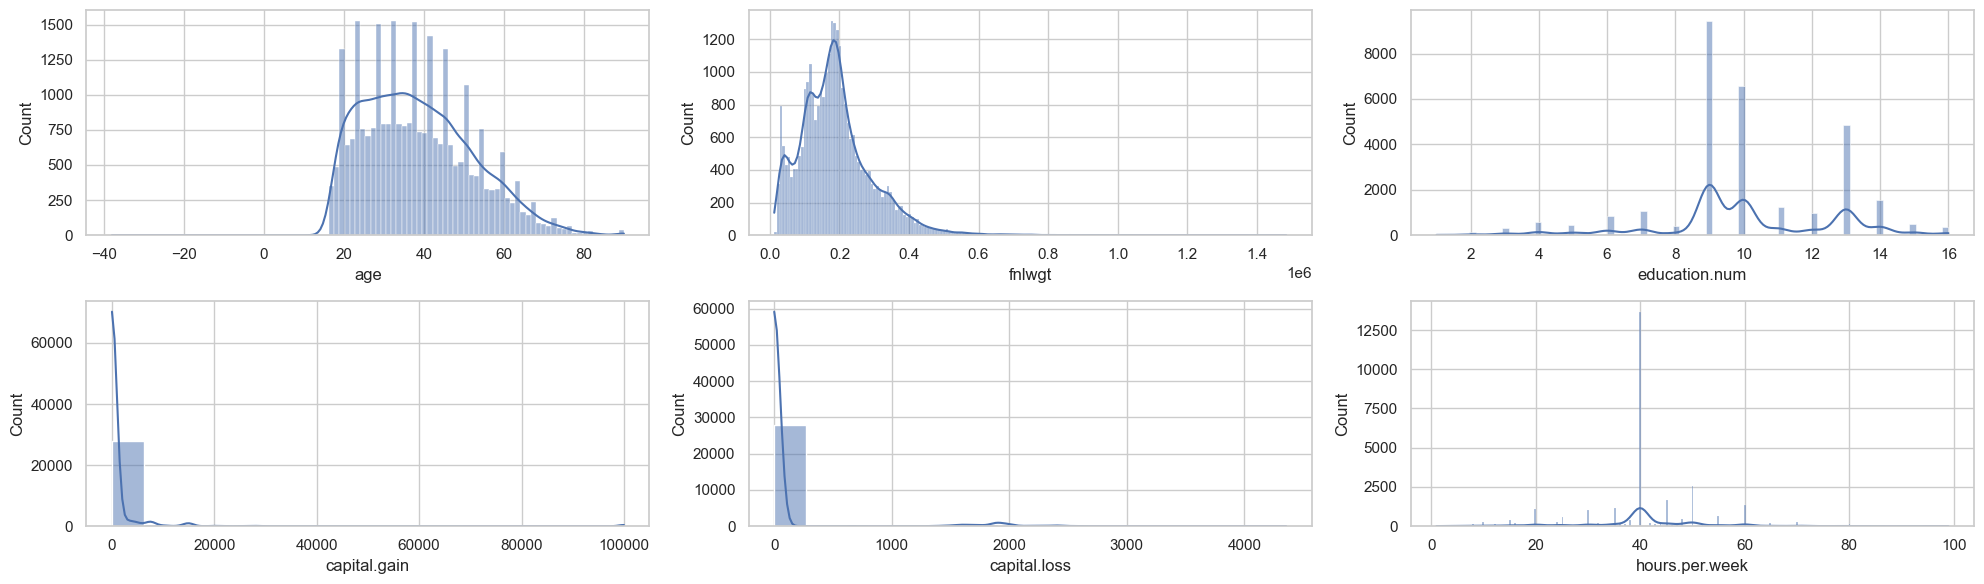

In [7]:
fig, axes = plt.subplots(2,3, figsize=(20,6))

sns.histplot(train['age'], kde=True, ax=axes[0][0])
sns.histplot(train['fnlwgt'], kde=True, ax=axes[0][1])
sns.histplot(train['education.num'], kde=True, ax=axes[0][2])
sns.histplot(train['capital.gain'], kde=True, ax=axes[1][0])
sns.histplot(train['capital.loss'], kde=True, ax=axes[1][1])
sns.histplot(train['hours.per.week'], kde=True, ax=axes[1][2])

plt.tight_layout()
plt.show()

In [8]:
train.describe(include='object')

,workclass,education,marital.status,occupation,relationship,race,sex,native.country,income
count,27642,29304,29304,27636,29304,29304,29304,28767,29304
unique,8,16,7,14,6,5,2,41,2
top,Private,HS-grad,Married-civ-spouse,Prof-specialty,Husband,White,Male,United-States,<=50K
freq,20451,9449,13466,3683,11845,25022,19578,26240,22263


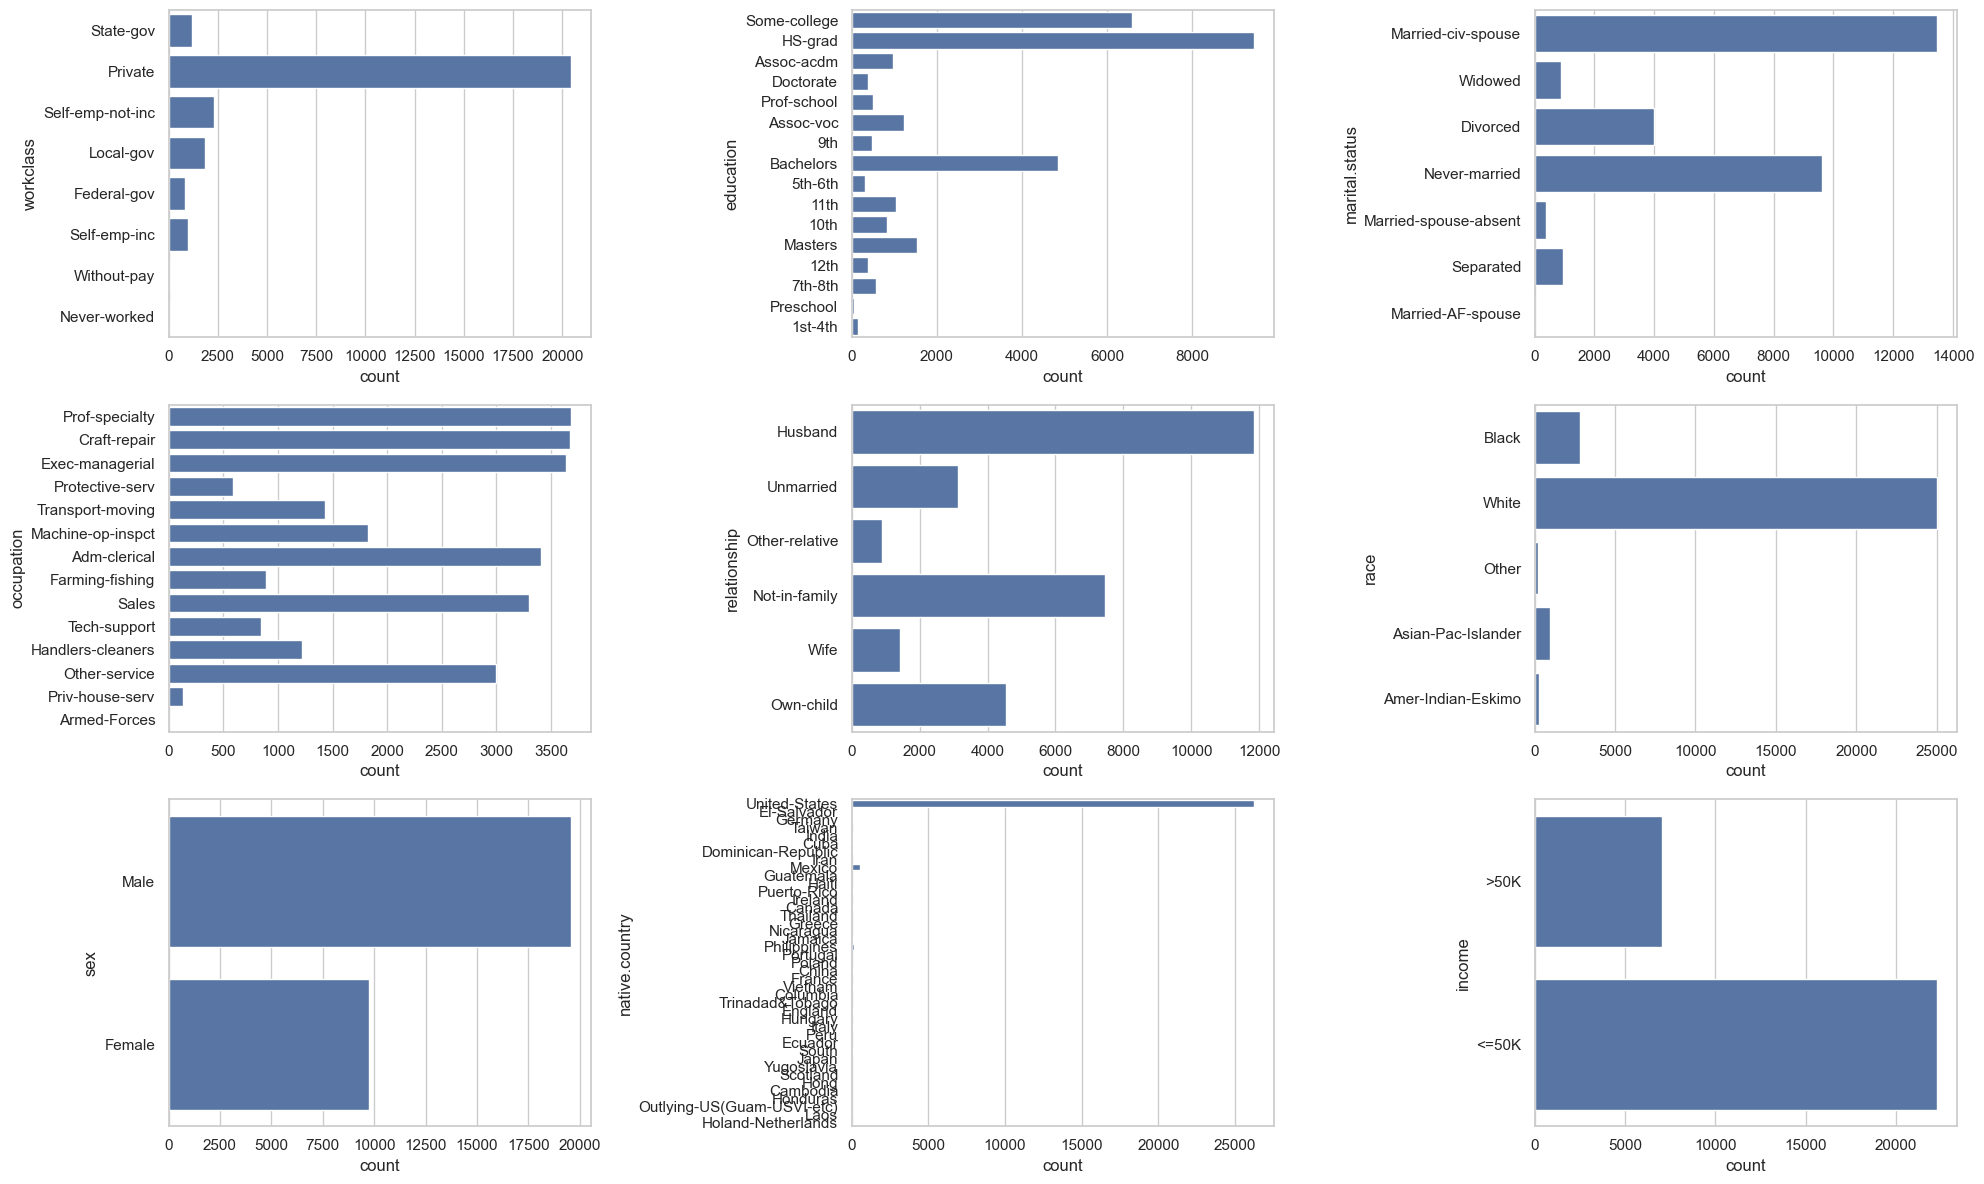

In [9]:
fig, axes = plt.subplots(3,3, figsize=(20,12))

sns.countplot(train['workclass'], ax=axes[0][0])
sns.countplot(train['education'], ax=axes[0][1])
sns.countplot(train['marital.status'], ax=axes[0][2])
sns.countplot(train['occupation'], ax=axes[1][0])
sns.countplot(train['relationship'], ax=axes[1][1])
sns.countplot(train['race'], ax=axes[1][2])
sns.countplot(train['sex'], ax=axes[2][0])
sns.countplot(train['native.country'], ax=axes[2][1])
sns.countplot(train['income'], ax=axes[2][2])

plt.tight_layout()
plt.show()

> 전처리 전략 수립 
  - id는 그냥 일련번호 --> 제거 
  - 그냥 제거하기에는 결측치가 상당히 많다  --> 적절한 대체 
  - age가 음수인 것이 있다. --> 제거 
  - 범주형 변수가 많다 --> 인코딩 
  - 수치형 변수들의 단위가 상이하고, 분포가 치우쳐져 있다. --> 이상치 제거, 스케일링 
  - 타겟변수(income)이 불균형하다. --> 검증데이터 분리시 편중 방지 

#### 2-2. 전처리

In [10]:
# 범주형 변수 결측치 처리 
## workclass, native.country --> 최빈값 대체 
## occupation --> 무직자(x)로 대체 

train['workclass'] = train['workclass'].fillna(train['workclass'].mode()[0])
train['native.country'] = train['native.country'].fillna(train['native.country'].mode()[0])
train['occupation'] = train['occupation'].fillna('x')

test['workclass'] = test['workclass'].fillna(test['workclass'].mode()[0])
test['native.country'] = test['native.country'].fillna(test['native.country'].mode()[0])
test['occupation'] = test['occupation'].fillna('x')

In [11]:
# 수치형 변수 결측치 처리 
## age, hours.per.week --> 평균대체 

train['age'] = train['age'].fillna(train['age'].mean())
train['hours.per.week'] = train['hours.per.week'].fillna(train['hours.per.week'].mean())

test['age'] = test['age'].fillna(test['age'].mean())
test['hours.per.week'] = test['hours.per.week'].fillna(test['hours.per.week'].mean())

In [12]:
# 결측치 제거결과 확인 
print(train.isnull().sum())
print('\n', test.isnull().sum())

id                0
age               0
workclass         0
fnlwgt            0
education         0
education.num     0
marital.status    0
occupation        0
relationship      0
race              0
sex               0
capital.gain      0
capital.loss      0
hours.per.week    0
native.country    0
income            0
dtype: int64

 id                0
age               0
workclass         0
fnlwgt            0
education         0
education.num     0
marital.status    0
occupation        0
relationship      0
race              0
sex               0
capital.gain      0
capital.loss      0
hours.per.week    0
native.country    0
dtype: int64


<Axes: xlabel='age', ylabel='Density'>

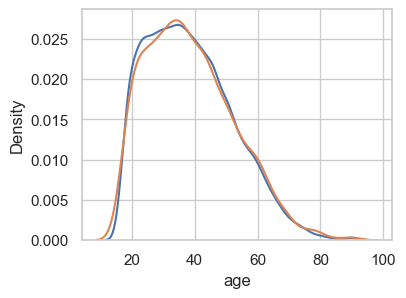

In [13]:
# 이상치 제거 : age에 음수가 존재할 수 없다 
train = train[train['age'] > 0]
test = test[test['age'] > 0]

plt.figure(figsize=(4,3))
sns.kdeplot(train['age'])
sns.kdeplot(test['age'])

In [14]:
# 타겟변수 y 분리, 0과 1로 변경 
y = train['income'].map({'<=50K':0, '>50K':1})
# 불필요한 id 컬럼 삭제 
train = train.drop(['id', 'income'], axis=1)
test = test.drop(['id'], axis=1)

수치형 컬럼 :  Index(['age', 'fnlwgt', 'education.num', 'capital.gain', 'capital.loss',
       'hours.per.week'],
      dtype='object')


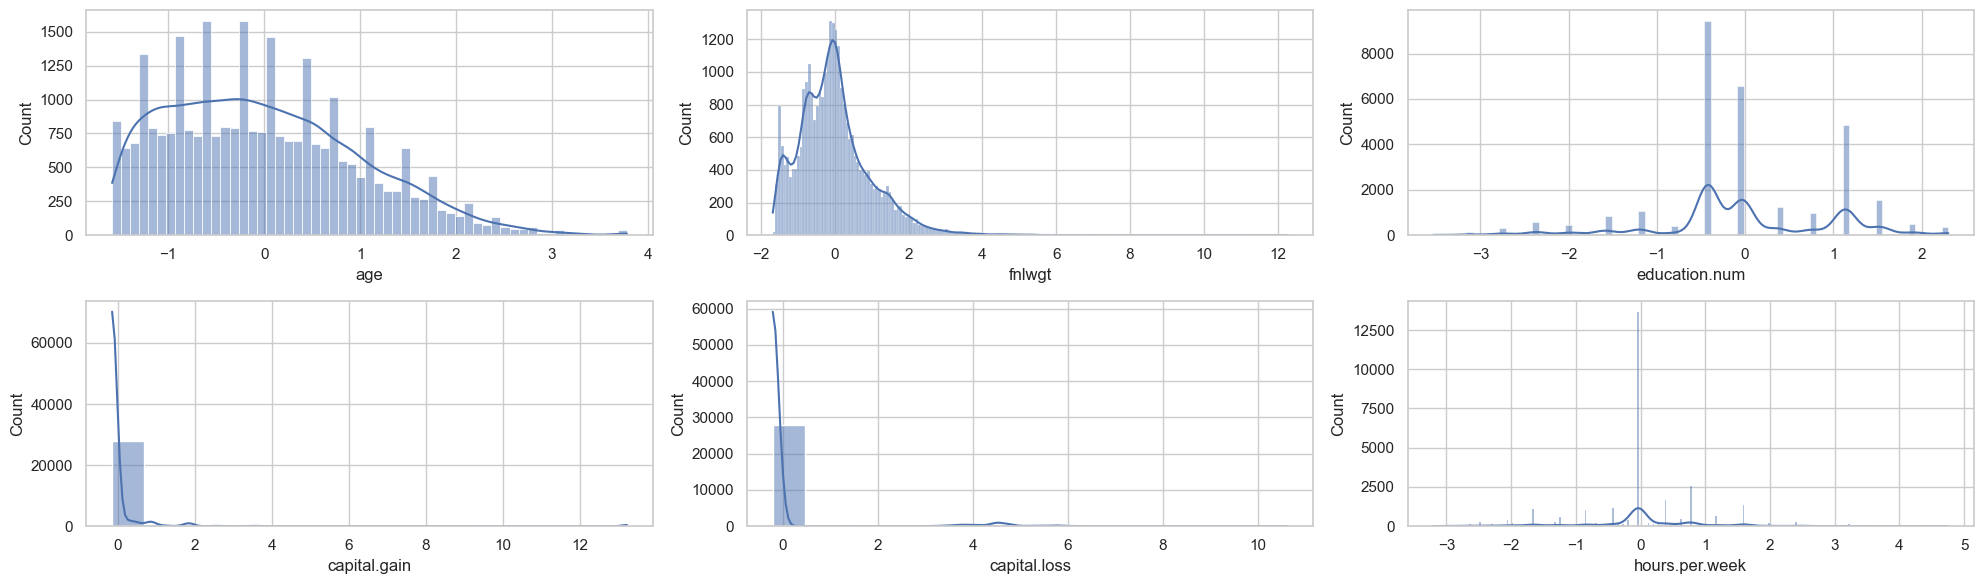

In [15]:
# 수치형 변수 스케일링 (선택)
num_cols = train.select_dtypes(exclude='object').columns
print('수치형 컬럼 : ', num_cols) 

from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
scaler = StandardScaler()

train[num_cols] = scaler.fit_transform(train[num_cols])
test[num_cols] = scaler.transform(test[num_cols])

# 스케일링결과 확인 
fig, axes = plt.subplots(2,3, figsize=(20,6))

sns.histplot(train['age'], kde=True, ax=axes[0][0])
sns.histplot(train['fnlwgt'], kde=True, ax=axes[0][1])
sns.histplot(train['education.num'], kde=True, ax=axes[0][2])
sns.histplot(train['capital.gain'], kde=True, ax=axes[1][0])
sns.histplot(train['capital.loss'], kde=True, ax=axes[1][1])
sns.histplot(train['hours.per.week'], kde=True, ax=axes[1][2])

plt.tight_layout()
plt.show()

In [16]:
print('인코딩 전 데이터 크기 : ', train.shape, test.shape)

# 원-핫 인코딩을 위해 train, test 데이터 임시 결합 
full = pd.concat([train, test], axis=0)

# 범주형 변수 원-핫 인코딩
full = pd.get_dummies(full, drop_first=True, dtype=int)

# 다시 train, test 분리 
train = full.iloc[:29301, :] 
test = full.iloc[29301:, :] 

print('인코딩 후 데이터 크기 : ', train.shape, test.shape)
train.head(2)

인코딩 전 데이터 크기 :  (29301, 14) (3257, 14)
인코딩 후 데이터 크기 :  (29301, 98) (3257, 98)


,age,fnlwgt,education.num,capital.gain,capital.loss,hours.per.week,workclass_Local-gov,workclass_Never-worked,workclass_Private,workclass_Self-emp-inc,...,native.country_Portugal,native.country_Puerto-Rico,native.country_Scotland,native.country_South,native.country_Taiwan,native.country_Thailand,native.country_Trinadad&Tobago,native.country_United-States,native.country_Vietnam,native.country_Yugoslavia
0,-0.335138,-0.117705,-0.031462,0.440247,-0.216056,-0.035137,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
1,1.428574,0.956277,-0.420430,-0.146298,-0.216056,-0.035137,0,0,1,0,...,0,0,0,0,0,0,0,1,0,0


#### 3. 학습/검증 데이터 분할 

In [17]:
from sklearn.model_selection import train_test_split
X_train, X_valid, y_train, y_valid = train_test_split(train, y, test_size=0.2, stratify=y, random_state=42)

print('분할 후 데이터 크기 : ', X_train.shape, X_valid.shape, y_train.shape, y_valid.shape)

분할 후 데이터 크기 :  (23440, 98) (5861, 98) (23440,) (5861,)


#### 4-1. Model 1 (RandomForest)

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

model_rf = RandomForestClassifier(class_weight='balanced', random_state=42)
model_rf.fit(X_train, y_train)

####################################################################################
# Accuracy / F1 → 결정된 결과(0/1) 평가 : model.predict() 사용 
# ROC-AUC → 확률의 순위 품질 평가(1을 잘 구분해낼 확률) : model.predict_proba() 사용 
####################################################################################

rf_pred = model_rf.predict(X_valid)
acc = accuracy_score(y_valid, rf_pred)
f1 = f1_score(y_valid, rf_pred)

rf_pred_proba = model_rf.predict_proba(X_valid)[:,1]
roc = roc_auc_score(y_valid, rf_pred_proba)

print('Accuracy = ', round(acc,4))
print('F1 score = ', round(f1,4))
print('ROC AUC score = ', round(roc,4))

Accuracy =  0.8521
F1 score =  0.6628
ROC AUC score =  0.9036


#### 4-2. Model 2 (LightGBM)

In [ ]:
#!pip install lightgbm

In [20]:
from lightgbm import LGBMClassifier

model_lgb = LGBMClassifier(class_weight='balanced', random_state=42)
model_lgb.fit(X_train, y_train)

lgb_pred = model_lgb.predict(X_valid)
acc = accuracy_score(y_valid, lgb_pred)
f1 = f1_score(y_valid, lgb_pred)

lgb_proba = model_lgb.predict_proba(X_valid)[:, 1]
roc = roc_auc_score(y_valid, lgb_proba)

print('Accuracy = ', round(acc,4))
print('F1 score = ', round(f1,4))
print('ROC AUC score = ', round(roc,4))

[LightGBM] [Info] Number of positive: 5631, number of negative: 17809
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002150 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 742
[LightGBM] [Info] Number of data points in the train set: 23440, number of used features: 82
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
Accuracy =  0.8364
F1 score =  0.7155
ROC AUC score =  0.9288


---
> 랜덤포레스트 
- Accuracy =  0.8521
- F1 score =  0.6628
- ROC AUC score =  0.9036

> LightGBM  
- Accuracy =  0.8364
- F1 score =  0.7155
- ROC AUC score =  0.9288

### 결론 : 정확도는 랜덤포레스트가 약간 우위이기는 하나, F1과 ROC AUC에서 L.GBM이 확연하게 우위
--- 

In [26]:
# 선택된 모델을 test 데이터에 적용 
pred = model_lgb.predict(test)

result = pd.read_csv("data/usa_people_test.csv")
result["Prediction"] = pred
result.to_csv('result.csv', index=False)